#📌 Extracción

In [1]:
import pandas as pd
import requests


In [2]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"


In [3]:
response = requests.get(url)
data = response.json()


In [4]:
df = pd.DataFrame(data)


In [5]:
df.head()


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


#🔧 Transformación

In [7]:
# Ver nombres de columnas
df.columns


Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

In [8]:
# Ver tipos de datos y valores nulos
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [9]:
df.describe()


,customerID,Churn,customer,phone,internet,account
count,7267,7267,7267,7267,7267,7267
unique,7267,3,891,3,129,6931
top,9995-HOTOH,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'No', 'OnlineSecurity': 'N...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
freq,1,5174,223,3495,1581,6


In [10]:
df.describe(include='object')


,customerID,Churn,customer,phone,internet,account
count,7267,7267,7267,7267,7267,7267
unique,7267,3,891,3,129,6931
top,9995-HOTOH,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'No', 'OnlineSecurity': 'N...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
freq,1,5174,223,3495,1581,6


In [11]:
df['Churn'].value_counts()


,count
Churn,
No,5174
Yes,1869
,224


In [13]:
df = pd.json_normalize(data)



In [14]:
df.columns


Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [16]:
df.columns.tolist()



['customerID',
 'Churn',
 'customer.gender',
 'customer.SeniorCitizen',
 'customer.Partner',
 'customer.Dependents',
 'customer.tenure',
 'phone.PhoneService',
 'phone.MultipleLines',
 'internet.InternetService',
 'internet.OnlineSecurity',
 'internet.OnlineBackup',
 'internet.DeviceProtection',
 'internet.TechSupport',
 'internet.StreamingTV',
 'internet.StreamingMovies',
 'account.Contract',
 'account.PaperlessBilling',
 'account.PaymentMethod',
 'account.Charges.Monthly',
 'account.Charges.Total']

In [18]:
data[0].keys()


dict_keys(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'])

In [17]:
type(data)


list

In [19]:
df = pd.json_normalize(
    data,
    sep='_'
)


In [20]:
df.columns.tolist()


['customerID',
 'Churn',
 'customer_gender',
 'customer_SeniorCitizen',
 'customer_Partner',
 'customer_Dependents',
 'customer_tenure',
 'phone_PhoneService',
 'phone_MultipleLines',
 'internet_InternetService',
 'internet_OnlineSecurity',
 'internet_OnlineBackup',
 'internet_DeviceProtection',
 'internet_TechSupport',
 'internet_StreamingTV',
 'internet_StreamingMovies',
 'account_Contract',
 'account_PaperlessBilling',
 'account_PaymentMethod',
 'account_Charges_Monthly',
 'account_Charges_Total']

In [22]:
cols_relevantes = [
    'customerID',
 'Churn',
 'customer_gender',
 'customer_SeniorCitizen',
 'customer_Partner',
 'customer_Dependents',
 'customer_tenure',
 'phone_PhoneService',
 'phone_MultipleLines',
 'internet_InternetService',
 'internet_OnlineSecurity',
 'internet_OnlineBackup',
 'internet_DeviceProtection',
 'internet_TechSupport',
 'internet_StreamingTV',
 'internet_StreamingMovies',
 'account_Contract',
 'account_PaperlessBilling',
 'account_PaymentMethod',
 'account_Charges_Monthly',
 'account_Charges_Total'
]

df_churn = df[cols_relevantes]


In [23]:
df_churn.head()


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [24]:
df_churn.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

In [25]:
df_churn.isnull().sum()


,0
customerID,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


In [27]:
df_churn['account_Charges_Total'].unique()[:10]


array(['593.3', '542.4', '280.85', '1237.85', '267.4', '571.45',
       '7904.25', '5377.8', '340.35', '5957.9'], dtype=object)

In [29]:
df.duplicated().sum()


np.int64(0)

In [30]:
df['customerID'].duplicated().sum()


np.int64(0)

In [32]:
df['account_Charges_Total'] = pd.to_numeric(
    df['account_Charges_Total'],
    errors='coerce'
)


In [35]:
df['account_Charges_Total'].isna().sum()


np.int64(0)

In [34]:
df['account_Charges_Total'] = df['account_Charges_Total'].fillna(0)


In [36]:
df.dtypes


,0
customerID,object
Churn,object
customer_gender,object
customer_SeniorCitizen,int64
customer_Partner,object
customer_Dependents,object
customer_tenure,int64
phone_PhoneService,object
phone_MultipleLines,object
internet_InternetService,object


In [37]:
df['Churn'].value_counts(normalize=True) * 100


,proportion
Churn,
No,71.198569
Yes,25.719004
,3.082427


In [38]:
df.groupby('Churn')['customer_tenure'].describe()


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
,224.0,31.571429,24.998552,1.0,7.0,29.0,56.0,72.0
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


In [39]:
df.groupby('Churn')['account_Charges_Monthly'].mean()


,account_Charges_Monthly
Churn,
,63.412277
No,61.265124
Yes,74.441332


In [40]:
df.groupby(['internet_InternetService', 'Churn']).size().unstack()


Churn,,No,Yes
internet_InternetService,,,
DSL,67,1962,459
Fiber optic,102,1799,1297
No,55,1413,113


In [41]:
df.groupby('internet_TechSupport')['Churn'].value_counts(normalize=True)


internet_TechSupport  Churn
No                    No       0.565885
                      Yes      0.403685
                               0.030430
No internet service   No       0.893738
                      Yes      0.071474
                               0.034788
Yes                   No       0.824144
                      Yes      0.147338
                               0.028517
Name: proportion, dtype: float64

In [42]:
df.groupby('internet_OnlineSecurity')['Churn'].value_counts(normalize=True)


internet_OnlineSecurity  Churn
No                       No       0.564579
                         Yes      0.404933
                                  0.030488
No internet service      No       0.893738
                         Yes      0.071474
                                  0.034788
Yes                      No       0.829644
                         Yes      0.141963
                                  0.028393
Name: proportion, dtype: float64

In [43]:
df.groupby('account_PaymentMethod')['Churn'].value_counts(normalize=True)


account_PaymentMethod      Churn
Bank transfer (automatic)  No       0.809314
                           Yes      0.162366
                                    0.028320
Credit card (automatic)    No       0.822704
                           Yes      0.147959
                                    0.029337
Electronic check           No       0.529243
                           Yes      0.438037
                                    0.032720
Mailed check               No       0.783183
                           Yes      0.184985
                                    0.031832
Name: proportion, dtype: float64

In [44]:
df_clean = df.copy()


In [45]:
df_clean['account_Charges_Total'] = pd.to_numeric(
    df_clean['account_Charges_Total'],
    errors='coerce'
)


In [46]:
df_clean['account_Charges_Total'] = df_clean['account_Charges_Total'].fillna(0)


In [47]:
internet_cols = [
    'internet_OnlineSecurity',
    'internet_OnlineBackup',
    'internet_DeviceProtection',
    'internet_TechSupport',
    'internet_StreamingTV',
    'internet_StreamingMovies'
]

for col in internet_cols:
    df_clean[col] = df_clean[col].replace('No internet service', 'No')


In [48]:
df_clean['phone_MultipleLines'] = df_clean['phone_MultipleLines'].replace(
    'No phone service', 'No'
)


In [49]:
cat_cols = df_clean.select_dtypes(include='object').columns

df_clean[cat_cols] = df_clean[cat_cols].apply(lambda x: x.str.strip())


In [50]:
df_clean.duplicated().sum()


np.int64(0)

In [51]:
df_clean['customerID'].duplicated().sum()


np.int64(0)

In [52]:
df_clean[
    (df_clean['customer_tenure'] == 0) &
    (df_clean['account_Charges_Total'] > 0)
]


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total


In [53]:
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

In [54]:
df_clean.isnull().sum()


,0
customerID,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


In [55]:
df_clean.head()


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


#📊 Carga y análisis

In [56]:
df_clean.describe()


,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly,account_Charges_Total
count,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098,2277.182035
std,0.369074,24.571773,30.129572,2268.648587
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.425000,396.200000
50%,0.000000,29.000000,70.300000,1389.200000
75%,0.000000,55.000000,89.875000,3778.525000
max,1.000000,72.000000,118.750000,8684.800000


In [57]:
num_cols = [
    'customer_tenure',
    'account_Charges_Monthly',
    'account_Charges_Total'
]

df_clean[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
customer_tenure,7267.0,32.346498,24.571773,0.00,9.000,29.0,55.000,72.00
account_Charges_Monthly,7267.0,64.720098,30.129572,18.25,35.425,70.3,89.875,118.75
account_Charges_Total,7267.0,2277.182035,2268.648587,0.00,396.200,1389.2,3778.525,8684.80


In [58]:
df_clean[num_cols].agg(['mean', 'median', 'std'])


,customer_tenure,account_Charges_Monthly,account_Charges_Total
mean,32.346498,64.720098,2277.182035
median,29.000000,70.300000,1389.200000
std,24.571773,30.129572,2268.648587


In [59]:
df_clean['Churn'].value_counts(normalize=True) * 100


,proportion
Churn,
No,71.198569
Yes,25.719004
,3.082427


In [60]:
df_clean['account_Contract'].value_counts(normalize=True) * 100


,proportion
account_Contract,
Month-to-month,55.112151
Two year,23.985138
One year,20.902711


In [61]:
df_clean['internet_InternetService'].value_counts(normalize=True) * 100


,proportion
internet_InternetService,
Fiber optic,44.007156
DSL,34.236962
No,21.755883


In [62]:
df_clean['internet_TechSupport'].value_counts(normalize=True) * 100


,proportion
internet_TechSupport,
No,71.0472
Yes,28.9528


In [63]:
df_clean.groupby('Churn')['customer_tenure'].describe()


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
,224.0,31.571429,24.998552,1.0,7.0,29.0,56.0,72.0
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


In [64]:
df_clean.groupby('Churn')['account_Charges_Monthly'].describe()


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
,224.0,63.412277,31.388712,18.75,28.425,69.100,90.4125,115.55
No,5174.0,61.265124,31.092648,18.25,25.100,64.425,88.4000,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.150,79.650,94.2000,118.35


In [65]:
df_clean['Churn'].value_counts()


,count
Churn,
No,5174
Yes,1869
,224


In [66]:
df_clean['Churn'].value_counts(normalize=True) * 100


,proportion
Churn,
No,71.198569
Yes,25.719004
,3.082427


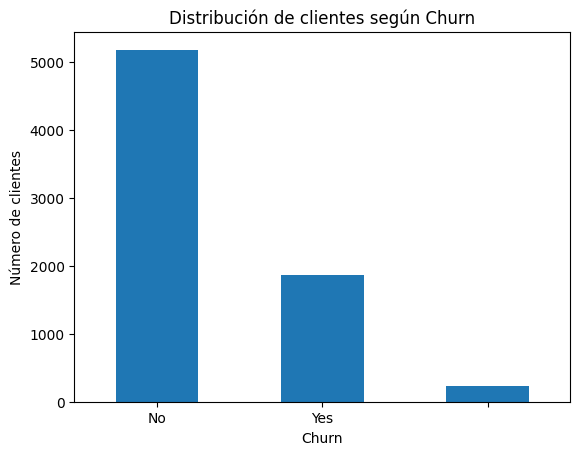

In [67]:
import matplotlib.pyplot as plt

churn_counts = df_clean['Churn'].value_counts()

plt.figure()
churn_counts.plot(kind='bar')
plt.title('Distribución de clientes según Churn')
plt.xlabel('Churn')
plt.ylabel('Número de clientes')
plt.xticks(rotation=0)
plt.show()


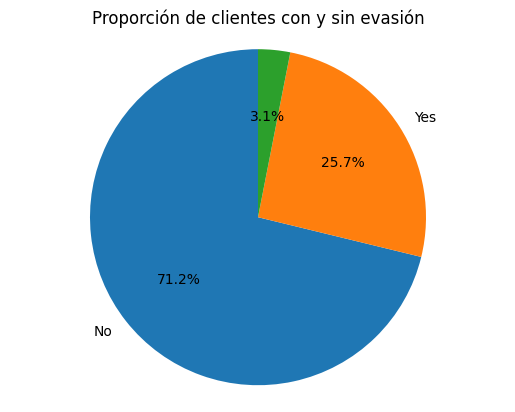

In [68]:
plt.figure()
plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Proporción de clientes con y sin evasión')
plt.axis('equal')
plt.show()


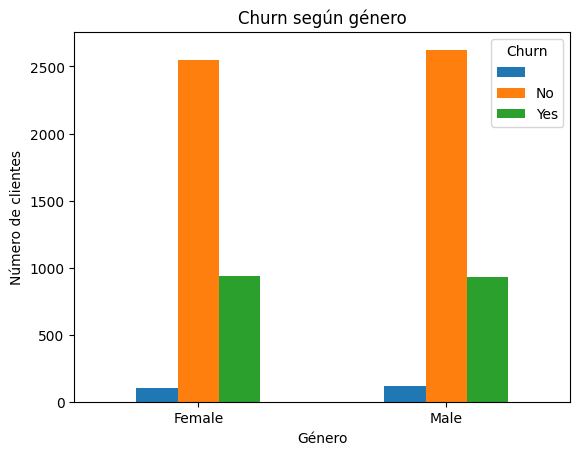

In [69]:
import matplotlib.pyplot as plt

churn_gender = (
    df_clean
    .groupby(['customer_gender', 'Churn'])
    .size()
    .unstack()
)

churn_gender.plot(kind='bar')
plt.title('Churn según género')
plt.xlabel('Género')
plt.ylabel('Número de clientes')
plt.xticks(rotation=0)
plt.show()


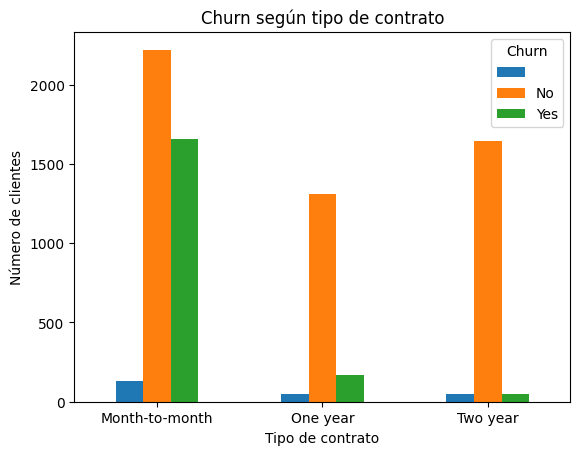

In [70]:
churn_contract = (
    df_clean
    .groupby(['account_Contract', 'Churn'])
    .size()
    .unstack()
)

churn_contract.plot(kind='bar')
plt.title('Churn según tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Número de clientes')
plt.xticks(rotation=0)
plt.show()


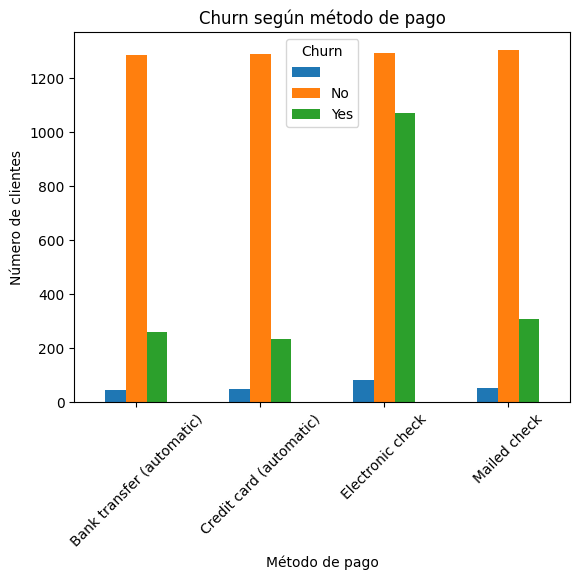

In [71]:
churn_payment = (
    df_clean
    .groupby(['account_PaymentMethod', 'Churn'])
    .size()
    .unstack()
)

churn_payment.plot(kind='bar')
plt.title('Churn según método de pago')
plt.xlabel('Método de pago')
plt.ylabel('Número de clientes')
plt.xticks(rotation=45)
plt.show()


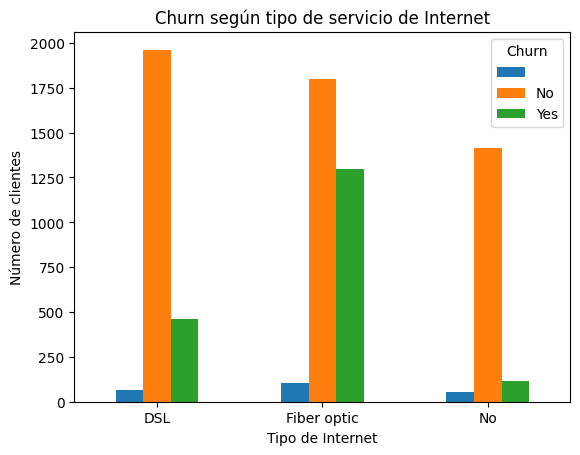

In [72]:
churn_internet = (
    df_clean
    .groupby(['internet_InternetService', 'Churn'])
    .size()
    .unstack()
)

churn_internet.plot(kind='bar')
plt.title('Churn según tipo de servicio de Internet')
plt.xlabel('Tipo de Internet')
plt.ylabel('Número de clientes')
plt.xticks(rotation=0)
plt.show()


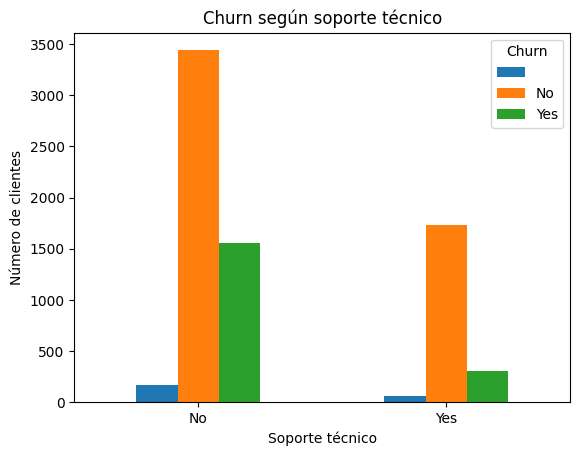

In [73]:
churn_support = (
    df_clean
    .groupby(['internet_TechSupport', 'Churn'])
    .size()
    .unstack()
)

churn_support.plot(kind='bar')
plt.title('Churn según soporte técnico')
plt.xlabel('Soporte técnico')
plt.ylabel('Número de clientes')
plt.xticks(rotation=0)
plt.show()


<Figure size 640x480 with 0 Axes>

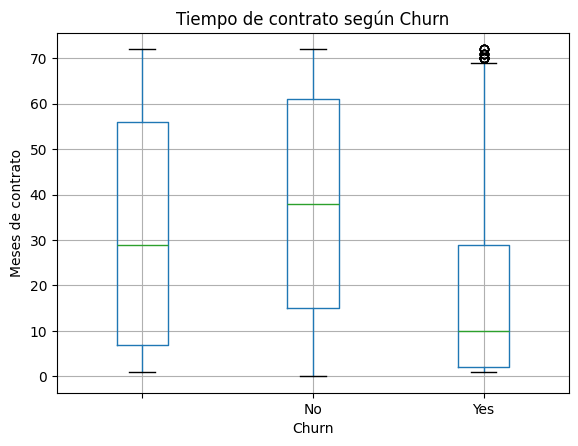

In [74]:
import matplotlib.pyplot as plt

plt.figure()
df_clean.boxplot(column='customer_tenure', by='Churn')
plt.title('Tiempo de contrato según Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Meses de contrato')
plt.show()


<Figure size 640x480 with 0 Axes>

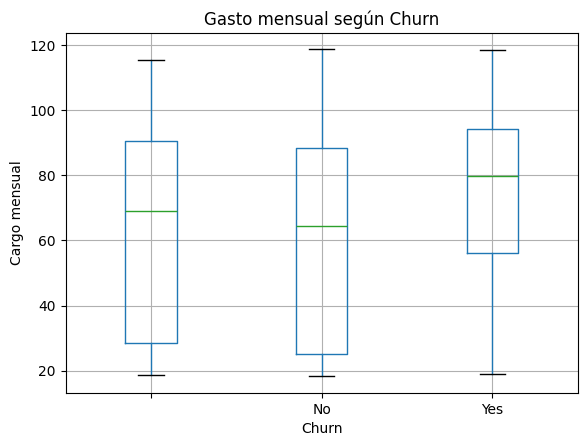

In [75]:
plt.figure()
df_clean.boxplot(column='account_Charges_Monthly', by='Churn')
plt.title('Gasto mensual según Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Cargo mensual')
plt.show()


<Figure size 640x480 with 0 Axes>

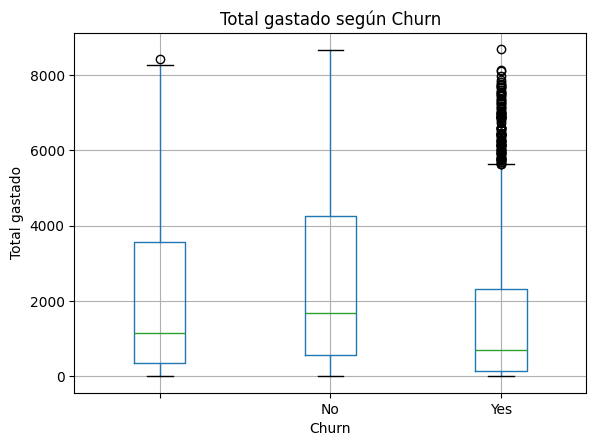

In [76]:
plt.figure()
df_clean.boxplot(column='account_Charges_Total', by='Churn')
plt.title('Total gastado según Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Total gastado')
plt.show()


<Figure size 640x480 with 0 Axes>

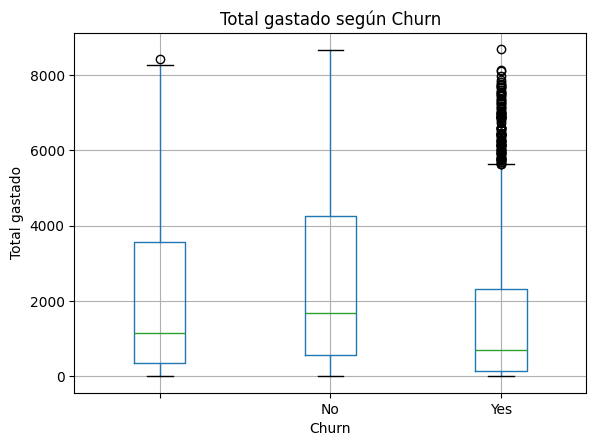

In [77]:
plt.figure()
df_clean.boxplot(column='account_Charges_Total', by='Churn')
plt.title('Total gastado según Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Total gastado')
plt.show()


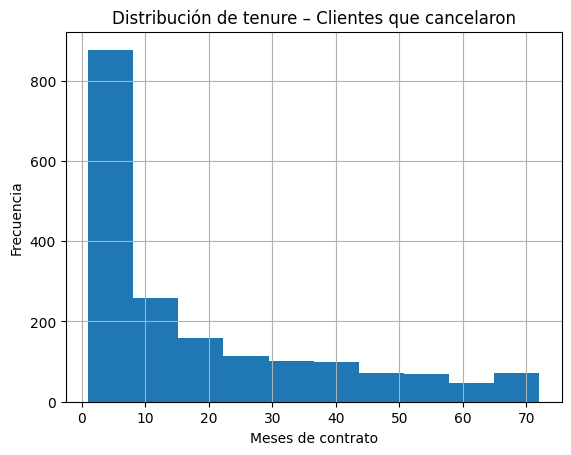

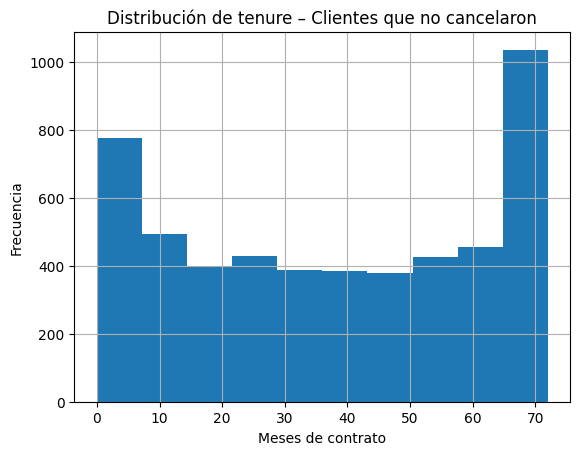

In [78]:
plt.figure()
df_clean[df_clean['Churn'] == 'Yes']['customer_tenure'].hist()
plt.title('Distribución de tenure – Clientes que cancelaron')
plt.xlabel('Meses de contrato')
plt.ylabel('Frecuencia')
plt.show()

plt.figure()
df_clean[df_clean['Churn'] == 'No']['customer_tenure'].hist()
plt.title('Distribución de tenure – Clientes que no cancelaron')
plt.xlabel('Meses de contrato')
plt.ylabel('Frecuencia')
plt.show()


#📄Informe final

🔹 Introducción

La evasión de clientes (Churn) es uno de los principales desafíos en el sector de telecomunicaciones, ya que la pérdida de clientes impacta directamente en los ingresos y la sostenibilidad del negocio.
El objetivo de este análisis es identificar patrones y factores asociados a la evasión de clientes en Telecom X, utilizando técnicas de análisis de datos para comprender el comportamiento de los usuarios y apoyar la toma de decisiones estratégicas orientadas a la retención.

A través del análisis de datos demográficos, servicios contratados, información contractual y cargos económicos, se busca responder a la pregunta clave:
¿Qué características aumentan la probabilidad de que un cliente cancele el servicio?

🔹 Limpieza y Tratamiento de Datos
Importación de datos

Los datos fueron cargados directamente desde una API en formato JSON alojada en GitHub.

Se utilizó pandas para convertir el JSON en un DataFrame.

Debido a que los datos estaban anidados, se aplicó pd.json_normalize() para aplanar la estructura.

Tratamiento y corrección de inconsistencias

Se realizaron las siguientes acciones clave:

✔️ Conversión de la variable account_Charges_Total a tipo numérico usando pd.to_numeric, corrigiendo errores de formato.

✔️ Reemplazo de valores nulos resultantes por 0, coherente con clientes nuevos (tenure = 0).

✔️ Normalización de categorías inconsistentes como:

"No internet service" → "No"

"No phone service" → "No"

✔️ Eliminación de espacios en blanco en variables categóricas.

✔️ Verificación de duplicados, asegurando la unicidad del customerID.

✔️ Validación de coherencia lógica entre tiempo de contrato y cargos totales.

Tras estos pasos, el dataset quedó completo, consistente y listo para análisis.

🔹 Análisis Exploratorio de Datos (EDA)
Distribución de la variable Churn

Se visualizó la proporción de clientes que permanecieron vs cancelaron mediante gráficos de barras y torta.

Se observó que el dataset presenta una proporción relevante de churn, lo que justifica el análisis y la necesidad de acciones de retención.

Análisis por variables categóricas

Se analizaron gráficos de barras cruzando Churn con variables clave:

Tipo de contrato:

Los clientes con contrato mes a mes presentan la mayor tasa de evasión.

Los contratos de 1 y 2 años muestran mayor estabilidad.

Método de pago:

Los pagos automáticos tienden a tener menor churn.

Servicios de soporte y seguridad:

La ausencia de soporte técnico y seguridad online está asociada a una mayor evasión.

Género:

No se observaron diferencias significativas en la evasión.

Análisis por variables numéricas

Mediante boxplots e histogramas se compararon clientes que cancelaron vs los que no:

Tiempo de contrato (tenure):

Clientes con menor antigüedad presentan mayor churn.

Gasto mensual:

Cargos mensuales más altos están asociados a mayor probabilidad de evasión.

Total gastado:

Clientes que no cancelan acumulan un mayor gasto total, reflejando mayor permanencia.

🔹 Conclusiones e Insights

A partir del análisis realizado, se destacan los siguientes hallazgos:

📌 La evasión se concentra principalmente en clientes nuevos.

📌 El contrato mes a mes es el mayor predictor de churn.

📌 Los cargos mensuales elevados incrementan el riesgo de cancelación.

📌 La falta de soporte técnico y seguridad online está fuertemente relacionada con la evasión.

📌 Variables demográficas como el género tienen un impacto mínimo.

Estos resultados muestran que el churn no ocurre al azar, sino que sigue patrones claros y accionables.

🔹 Recomendaciones Estratégicas

Con base en los insights obtenidos, se proponen las siguientes acciones:

Incentivar contratos de largo plazo

Ofrecer descuentos o beneficios por migrar de contratos mensuales a anuales.

Fortalecer la retención temprana

Programas de bienvenida y seguimiento para clientes con baja antigüedad.

Optimizar planes de alto costo

Revisar la percepción de valor en clientes con cargos mensuales elevados.

Promover servicios de soporte y seguridad

Incluir soporte técnico y seguridad online como paquetes promocionales.

Fomentar métodos de pago automáticos

Bonificaciones por afiliación a pagos electrónicos recurrentes.

🚀 Cierre

Este análisis proporciona una base sólida para la toma de decisiones estratégicas orientadas a reducir la evasión de clientes en Telecom X.
Los resultados pueden ser utilizados tanto para acciones comerciales inmediatas como para el desarrollo de modelos predictivos de churn que permitan anticiparse a la pérdida de clientes.